Hi Tom,

I am sending you measured data for the peer review of our recently published results of a period-luminosity calibration for Cepheid variables. We assumed a relation in the form:

$$M = a [\log_{10}(P) - 1] + b.$$

The data I am sending you contain a database of our observations converted to PDF. Data has been partly corrupted, so not all rows contain all data — discard incomplete rows and use only those where a galaxy spectrum, an estimated Cepheid period, and its mean apparent magnitude are all available.

We assumed that the redshift of a Cepheid in a galaxy equals the redshift of the whole galaxy due to cosmological expansion. We assumed the validity of Hubble's law in the form:

$$v_{\text{rec}} = H_0 \cdot d$$

across the whole provided dataset. We used $H_0 = 67\,\text{km}\,\text{s}^{-1}\,\text{Mpc}^{-1}$ and performed template cross-correlation in log-$\lambda$ space to estimate galaxy redshifts. Since the redshifts are small, we assumed classical formula for the redshift.

To verify our results, please send us the following:

1. A PDF table with two columns — one listing Cepheids ordered by their ID and the other showing the estimated redshifts to 5 decimal places for these Cepheid.
2. A plot of the data points used for the fit, including the best-fit straight line motivated by the period-luminosity relation.
3. A TXT file clearly stating the estimated fit parameters with uncertainties derived from the linear regression.

Best regards

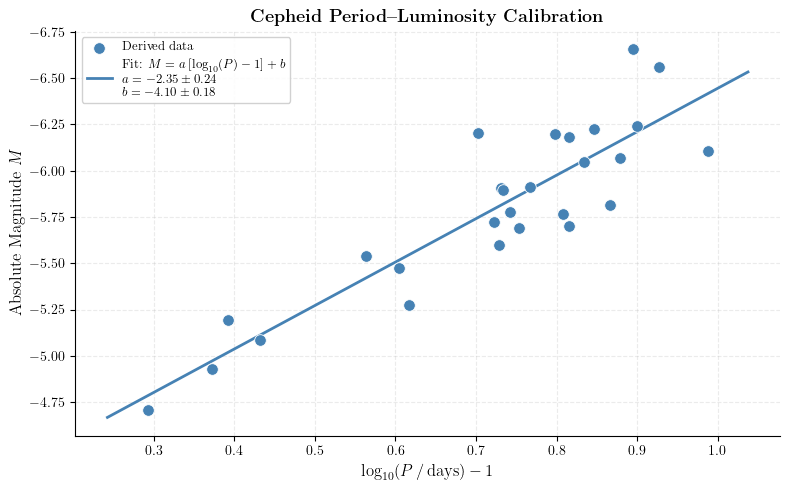

Slope:     -2.347 ± 0.238  (canonical: -2.43)
Intercept: -4.099 ± 0.177  (canonical: -4.05)


In [ ]:
import numpy as np
import random
import pandas as pd
import string
import math
import matplotlib.pyplot as plt
import os
import shutil
from matplotlib.ticker import MultipleLocator, FuncFormatter
from scipy.signal import correlate
from collections import defaultdict
from scipy import stats
from matplotlib.backends.backend_pdf import PdfPages

############################################################
################ Set initial parameters
############################################################
#Path to save outputs
path = "/Users/ondra/Outlier/SpideyMM_project/cepheides/input_data/"
os.chdir(path)
spectra_folder = 'spectra'
shutil.rmtree(spectra_folder)
os.makedirs(spectra_folder)

#Input parameters
c = 299792.458 #km/s
SIGMA_DISTANCE_CEPHEIDES = 0.1
Z_MAX = 0.05
N_GALAXIES = 8000
H = 67
CEPHEID_GENERATE_PROBABILITY = 0.5
SPECTRUM_GENERATE_PROBABILITY = 0.006
READING_PRECISION = 0.2 #nm

# Laboratory spectrum
LAB_SPECTRUM = {656.3: 1.0, 500.7: 0.9, 589.0: 0.85, 589.6: 0.8, 486.1: 0.75, 495.9: 0.65, 587.6: 0.6, 658.3: 0.55, 654.8: 0.5, 434.0: 0.45, 671.6: 0.38, 673.1: 0.34, 410.2: 0.3, 667.8: 0.27, 630.0: 0.23, 518.4: 0.2, 447.1: 0.17, 422.7: 0.15, 636.4: 0.12, 438.3: 0.1}

#Dataframe format
df = pd.DataFrame({ 'index': pd.Series(dtype='int'),
                    'galaxy_ID': pd.Series(dtype='str'),
                    'z' : pd.Series(dtype='float'),
                    'spectrum' : pd.Series(dtype='object'),
                    'true_distance [pc]' : pd.Series(dtype='float'),
                    'cepheid_ID': pd.Series(dtype='str'),
                    'cepheid_distance [pc]' : pd.Series(dtype='float'),
                    'mean_mag_cepheid': pd.Series(dtype='float'),
                    'period [days]': pd.Series(dtype='float'),
                    'z_estimated' : pd.Series(dtype='float'),
                    'sigma_z_estimated' : pd.Series(dtype='float'),
                    'z_allowed_interval' : pd.Series(dtype='str'),
                    'distance_estimated [pc]' : pd.Series(dtype='float'),
                    'absolute_mag_estimated' : pd.Series(dtype='float')})

############################################################
################ Function to produce graphical spectra
############################################################
def plot_spectrum(input_spectrum: dict[float, float], title: str = '', name: str = '', save_to: str = path) -> None:
    def gaussian(x, mu, sigma, amplitude):
        return amplitude * np.exp(-(x - mu) ** 2 / (2 * sigma ** 2))

    wavelength = np.linspace(400, 750, 7000)
    intensity = np.zeros_like(wavelength)
    for mu, amp in input_spectrum.items():
        intensity += gaussian(wavelength, mu, sigma=0.1, amplitude=amp)
    intensity /= intensity.max()

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(wavelength, intensity, color='white', linewidth=0.8)
    ax.fill_between(wavelength, intensity, alpha=0.4, color='cyan')
    ax.set_facecolor('black')
    fig.patch.set_facecolor('black')

    ax.set_title(title, color='white')
    ax.set_xlabel("Wavelength (nm)", color='white')
    ax.set_ylabel("Relative Intensity", color='white')
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('white')

    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    ax.tick_params(axis='x', which='major', length=8, colors='white')
    ax.tick_params(axis='x', which='minor', length=4, colors='white')
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'{int(x)}' if x % 50 == 0 else ''))

    ax.set_xlim(400, 750)
    ax.set_ylim(0, 1.05)

    plt.tight_layout()
    #plt.show()
    plt.savefig(f"{save_to}/{name}.png", dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.close()


plot_spectrum(LAB_SPECTRUM, 'Spectrum from the laboratory (400 - 750 nm)', "spectral_lines_lab", save_to=path)

############################################################
################ Function simulating reading error
############################################################
def apply_reading_error(spectrum: dict, resolution: float = READING_PRECISION) -> dict:
    """Round wavelengths to nearest multiple of `resolution` nm.
    If two lines collide, keep the brighter one (or sum them — see comment)."""
    rounded = defaultdict(float)
    for wl, amp in spectrum.items():
        key = round(wl / resolution) * resolution
        rounded[key] = max(rounded[key], amp)   # or: rounded[key] += amp to sum
    return dict(rounded)

############################################################
################ Function doing the spectral lines fit
############################################################
def estimate_z_logspace(observed_spectrum: dict, lab_spectrum: dict,
                         wav_min=400, wav_max=750, n_pts=7000) -> tuple[float, float]:
    log_wav = np.linspace(np.log(wav_min), np.log(wav_max), n_pts)

    def make_intensity_log(spectrum):
        inten = np.zeros(n_pts)
        for mu, amp in spectrum.items():
            log_mu = np.log(mu)
            inten += amp * np.exp(-(log_wav - log_mu)**2 / (2 * 0.0003**2))
        return inten / inten.max()

    lab_inten = make_intensity_log(apply_reading_error(lab_spectrum))
    obs_inten = make_intensity_log(apply_reading_error(observed_spectrum))

    corr = correlate(obs_inten, lab_inten, mode='full')
    lags = np.arange(-(n_pts - 1), n_pts)
    best_idx = np.argmax(corr)
    best_lag = lags[best_idx]

    # Fit parabola around the peak using 5 neighbouring points
    half_w = 5
    idx_lo = max(best_idx - half_w, 0)
    idx_hi = min(best_idx + half_w + 1, len(corr))
    local_lags = lags[idx_lo:idx_hi]
    local_corr = corr[idx_lo:idx_hi]
    coeffs = np.polyfit(local_lags, local_corr, 2)   # a*x^2 + b*x + c
    # Peak of parabola at x = -b/2a, width ~ 1/sqrt(-a)
    a_coeff = coeffs[0]
    sigma_lag = 1.0 / np.sqrt(-a_coeff) if a_coeff < 0 else np.nan

    log_wav_per_sample = (np.log(wav_max) - np.log(wav_min)) / n_pts
    delta_log_wav       = best_lag * log_wav_per_sample
    sigma_log_wav       = sigma_lag * log_wav_per_sample

    z      = np.exp(delta_log_wav) - 1 # z = e^(Δlog λ) - 1
    sigma_z = np.exp(delta_log_wav) * sigma_log_wav   # error propagation

    return z, sigma_z

############################################################
################ Loop to generate data files
############################################################
for i in range(N_GALAXIES):
    random.seed(42 + i)
    np.random.seed(42 + i)
    index = i
    galaxy_ID = 'G_' + ''.join(random.choices(string.digits, k=8))

    if np.random.uniform(0,1) < SPECTRUM_GENERATE_PROBABILITY:
        z = random.uniform(0.2,1)*Z_MAX
        LINE_VISIBLE_PROBABILITY = 0.5
        spectrum = {}
        for line in LAB_SPECTRUM.keys():
            shifted_line = line * (z + 1)
            if random.uniform(0,1) < LINE_VISIBLE_PROBABILITY:
                spectrum[shifted_line] = LAB_SPECTRUM[line]
        plot_spectrum(spectrum, f"Observed spectrum - {galaxy_ID}", galaxy_ID, path + spectra_folder)
    else:
        z = np.nan
        spectrum = {}

    true_distance = float(z*c/H * 10**6)
    if np.random.uniform(0,1) < CEPHEID_GENERATE_PROBABILITY:
        cepheid_ID = 'CEPH_' + ''.join(random.choices(string.digits, k=8))
        cepheid_distance = np.random.normal(loc=true_distance, scale=true_distance*SIGMA_DISTANCE_CEPHEIDES) #pc
        period = abs(np.random.normal(loc=60, scale=20))
        if not np.isnan(true_distance):
            mean_mag = -2.43*(math.log10(period) - 1) - 4.05 - 5 + 5*math.log10(cepheid_distance)
        else:
            # This is dirty trick to confuse model when I merge some cells in the csv table  and gives some unrealistic
            #  values of magnitude in the table (while not being so obvious), which can propagate to the result if the table
            # is not parsed correctly. These values are only for cepheids without redshift information, so they don't matter
            # for the analysis.
            mean_mag = -2.43*(math.log10(period * (1 + np.random.normal(loc=0, scale=0.3)) + 15) - 1) - 4.05 - 5 + 5*math.log10(cepheid_distance) + np.random.normal(loc=2, scale=2)
    else:
        cepheid_ID = np.nan
        cepheid_distance = np.nan
        period = np.nan
        mean_mag = np.nan

    if not np.isnan(z) and spectrum:
        estimated_z, sigma_z = estimate_z_logspace(spectrum, LAB_SPECTRUM, wav_min=400, wav_max=750, n_pts=7000)
        distance_estimated = estimated_z * c / H * 10**6
        interval = f"[{z-0.0001:.5f}; {z+0.0001:.5f}]"
    else:
        estimated_z = np.nan
        sigma_z = np.nan
        distance_estimated = np.nan
        interval = np.nan

    if not np.isnan(mean_mag) and not np.isnan(distance_estimated) and distance_estimated > 0:
        absolute_mag_estimated = mean_mag + 5 - 5 * math.log10(distance_estimated)
    else:
        absolute_mag_estimated = np.nan

    new_row = pd.DataFrame([{'index' : index,
                             'galaxy_ID' : galaxy_ID,
                             'z' : z,
                             'spectrum' : spectrum,
                             'true_distance [pc]' : true_distance,
                             'cepheid_ID' : cepheid_ID,
                             'cepheid_distance [pc]' : cepheid_distance,
                             'mean_mag_cepheid' : mean_mag,
                             'period [days]' : period,
                             'z_estimated': estimated_z,
                             'sigma_z_estimated': sigma_z,
                             'z_allowed_interval' : interval,
                             'distance_estimated [pc]' : distance_estimated,
                             'absolute_mag_estimated' : absolute_mag_estimated}])
    df = pd.concat([df, new_row], ignore_index=True)

############################################################
################ Prepare input data
############################################################
#Print data that can be estimated
df_est = df.copy()
df_est['z'] = df['z'].round(4)
df_est['mean_mag_cepheid'] = df['mean_mag_cepheid'].round(3)
df_est['period [days]'] = df['period [days]'].round(4)

#Print cepheides to .csv file
df_out = df_est.copy()
df_out['mean_mag_cepheid']                    = df_est['mean_mag_cepheid'].map('{:.3f}'.format)
df_out['period [days]'] = df_est['period [days]'].map('{:.4f}'.format)
df_out[['galaxy_ID' , 'cepheid_ID', 'mean_mag_cepheid', 'period [days]']].to_csv(path + "/cepheides_mesurements.csv", index=False)

#zip files to submission file
import shutil
#os.chdir(path + "../")
shutil.make_archive(
    base_name='observed_spectra',   # name of the zip file (without .zip)
    format='zip',
    root_dir='.',         # directory to start from
    base_dir='spectra'  # folder to zip
    )

#df

############################################################
################ Plot graph - solution
############################################################
# Collect fit data
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
df_fit = df[df['period [days]'].notna() & df['absolute_mag_estimated'].notna()].copy()
df_fit['logP_m1'] = np.log10(df_fit['period [days]']) - 1

x = df_fit['logP_m1'].values
y = df_fit['absolute_mag_estimated'].values

slope, intercept, r_value, _, _ = stats.linregress(x, y)

# uncertainty estimates
n   = len(x)
y_pred    = slope * x + intercept
s2        = np.sum((y - y_pred)**2) / (n - 2)
sxx       = np.sum((x - x.mean())**2)
se_slope  = np.sqrt(s2 / sxx)
se_inter  = np.sqrt(s2 * (1/n + x.mean()**2 / sxx))

# Plot
x_line = np.linspace(x.min() - 0.05, x.max() + 0.05, 300)

fig, ax = plt.subplots(figsize=(8, 5))

# data points
ax.scatter(x, y, color='steelblue', s=70, zorder=3,
           edgecolors='white', linewidths=0.6, label='Derived data')

# fitted line
fit_label = (
    f'Fit:  $M = a\\,[\\log_{{10}}(P) - 1] + b$\n'
    f'$a = {slope:.2f} \\pm {se_slope:.2f}$\n'
    f'$b = {intercept:.2f} \\pm {se_inter:.2f}$'
)

ax.plot(x_line, slope * x_line + intercept,
        color='steelblue', lw=2, label=fit_label)

# axes & styling
ax.invert_yaxis()   # brighter = smaller M = top of plot
ax.set_xlabel(r'$\log_{10}(P\,/\,\mathrm{days}) - 1$', fontsize=12)
ax.set_ylabel(r'Absolute Magnitude $M$', fontsize=12)
ax.set_title('\\textbf{Cepheid Period–Luminosity Calibration}', fontsize=13, fontweight='bold')

ax.legend(fontsize=9, framealpha=0.9, loc='upper left')
ax.grid(True, alpha=0.25, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(path + "../golden_solution/" + "cepheids_calibration.png", dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

############################################################
################ Output estimated redshifts pdf - solution
############################################################
df_filtered = df_out.loc[df_out['cepheid_ID'].notna() & df_out['mean_mag_cepheid'].notna() & df_out['period [days]'].notna() & df_out['z_estimated'].notna()].copy()
df_filtered.sort_values(by='cepheid_ID', ascending=True, inplace=True)
df_out_pdf = df_filtered[['cepheid_ID', 'z_estimated']].reset_index(drop=True)
df_out_pdf['z_estimated'] = df_out_pdf['z_estimated'].map('{:.5f}'.format)

with PdfPages(path + "../golden_solution/redshifts.pdf") as pdf:
    fig, ax = plt.subplots(figsize=(6, len(df_out_pdf) * 0.3 + 1))
    ax.axis('off')
    table = ax.table(
        cellText=df_out_pdf.values,
        colLabels=['\\textbf{Cepheid ID}', '\\textbf{Redshift}'],
        cellLoc='center',
        loc='center'
    )
    table.auto_set_font_size(True)
    table.scale(1, 1.4)
    for (row, col), cell in table.get_celld().items():
        if row == 0:  # header row
            cell.set_text_props(fontweight='bold')
    pdf.savefig(fig, bbox_inches='tight')
    plt.close()

############################################################
################ Output txt report - solution
############################################################

a_str = f"a = {slope:.3f} ± {se_slope:.3f}"
b_str = f"b = {intercept:.3f} ± {se_inter:.3f}"
width = max(len(a_str), len(b_str)) + 4

box = (
    f"┌{'─' * width}┐\n"
    f"│  {a_str:<{width-2}}│\n"
    f"│  {b_str:<{width-2}}│\n"
    f"└{'─' * width}┘"
)

with open(path + '../golden_solution/cepheid_period-luminosity.txt', 'w') as f:
    print(
        f'We assumed the period-luminosity calibration for Cepheid variables\n'
        f'in form M = a[log(P) - 1] + b.\n\n'
        f'Parameters estimated by our analysis are:\n\n'
        f'{box}',
        file=f
    )

############################################################
################ Estimated parameters for quick check - solution
############################################################
print(f"Slope:     {slope:.3f} ± {se_slope:.3f}  (canonical: -2.43)")
print(f"Intercept: {intercept:.3f} ± {se_inter:.3f}  (canonical: -4.05)")



In [52]:
df[['cepheid_ID', 'z', 'z_estimated', 'sigma_z_estimated', 'z_allowed_interval']].dropna().sort_values('cepheid_ID')

,cepheid_ID,z,z_estimated,sigma_z_estimated,z_allowed_interval
2636,CEPH_012933,0.021306,0.021419,0.000172,[0.02121; 0.02141]
3589,CEPH_023288,0.027089,0.027122,0.000164,[0.02699; 0.02719]
989,CEPH_115474,0.042329,0.042361,0.000177,[0.04223; 0.04243]
3431,CEPH_143087,0.034490,0.034528,0.000180,[0.03439; 0.03459]
2827,CEPH_154552,0.042298,0.042174,0.000230,[0.04220; 0.04240]
1004,CEPH_188335,0.043273,0.043297,0.000198,[0.04317; 0.04337]
1942,CEPH_244371,0.025431,0.025463,0.000187,[0.02533; 0.02553]
210,CEPH_302019,0.028225,0.028322,0.000246,[0.02812; 0.02832]
1943,CEPH_313557,0.044793,0.044891,0.000196,[0.04469; 0.04489]
1255,CEPH_338090,0.042106,0.042174,0.000187,[0.04201; 0.04221]
